In [2]:
import pandas as pd

df = pd.read_csv('./Data/syriatel_data.csv')

df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Business Understanding
Predict whether or not a customer will leave the company

Objective: Build a classifier to predict whether a customer will ("soon") stop doing business with SyriaTel, a telecommunications company

## Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

The data contains no empty cells. No imputation is needed.

Columns of interest:

`state`: The US state where the customer resides (represented by a 2-letter abbreviation, e.g., KS for Kansas, OH for Ohio).

`account length`: The number of days the customer has had an active account with the company.

`international plan`: A binary feature (yes or no) indicating whether the customer pays for an international calling plan.

`voice mail plan`: A binary feature (yes or no) indicating whether the customer pays for a voicemail plan.

`total [time] minutes`: The total number of minutes the customer spent on calls during that specific time (day, evening, night, international) period.

`total [time] calls`: The total count of individual phone calls the customer made/received during that time period.

`total [time] charge`: The monetary amount the telecom company billed the customer for that specific usage

`customer service calls`: The number of times the customer has called the telecom's customer service/support line. High numbers here are often a strong indicator of customer frustration.

`churn`: This is the target variable. A boolean feature (True or False) indicating whether the customer ultimately cancelled their service ("churned") or stayed with the company.

Other columns:

`area code`: The 3-digit area code of the customer's phone number

`number vmail messages`: The number of voicemail messages the customer currently has. (If they don't have a voicemail plan, this number is usually 0)

`phone number`: The customer's 7-digit phone number. In this dataset, it essentially acts as a unique identifier for the customer.

More information about the columns is located in [SyriaTel_Dataset_Feature_Dictionary](./Data/SyriaTel_Dataset_Feature_Dictionary.txt)

I will do some feature engineering on the boolean columns `churn`, `international plan` and `voice mail plan` to convert them to easy-to-work-with integers

In [4]:
# Convert boolean churn to 1 and 0
df['churn'] = df['churn'].astype(int)

# Convert 'yes'/'no' string columns to 1 and 0
df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

df[['international plan', 'voice mail plan', 'churn']].head()

,international plan,voice mail plan,churn
0,0,1,0
1,0,1,0
2,0,0,0
3,1,0,0
4,1,0,0


I will see how `churn` correlates with the other numeric columns

In [5]:
# I will do it on a copy to prevent destroying the original
df_corr = df.copy()

# Drop non-numeric and irrelevant columns
df_corr_numeric = df_corr.drop(columns=['state', 'phone number'])

# Calculate the correlation and sort it
churn_corr = df_corr_numeric.corr()['churn'].sort_values(ascending=False)

churn_corr

churn                     1.000000
international plan        0.259852
customer service calls    0.208750
total day minutes         0.205151
total day charge          0.205151
total eve minutes         0.092796
total eve charge          0.092786
total intl charge         0.068259
total intl minutes        0.068239
total night charge        0.035496
total night minutes       0.035493
total day calls           0.018459
account length            0.016541
total eve calls           0.009233
area code                 0.006174
total night calls         0.006141
total intl calls         -0.052844
number vmail messages    -0.089728
voice mail plan          -0.102148
Name: churn, dtype: float64

As can be seen churn is most positively correlated with whether or not the user has an international plan and most negatively correlated with whether or not the user had a voice mail plan

I will visualize the number of people with international plans who churned and didn't churn

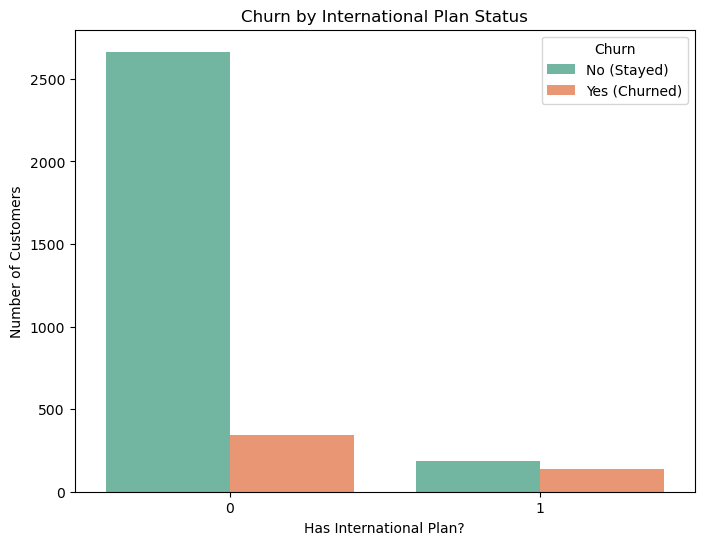

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(8, 6))

# Create a countplot
# x puts 'international plan' categories on the bottom axis
# hue splits the bars based on 'churn' status
sns.countplot(data=df, x='international plan', hue='churn', palette='Set2')

# Add clear labels and a title
plt.title('Churn by International Plan Status')
plt.xlabel('Has International Plan?')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'])

# Display the plot
plt.show()

A very good predictor of whether or not a customer churns is whether or not they have an international plan. Those without overwhemingly tend to stay. Visualized as percentages:

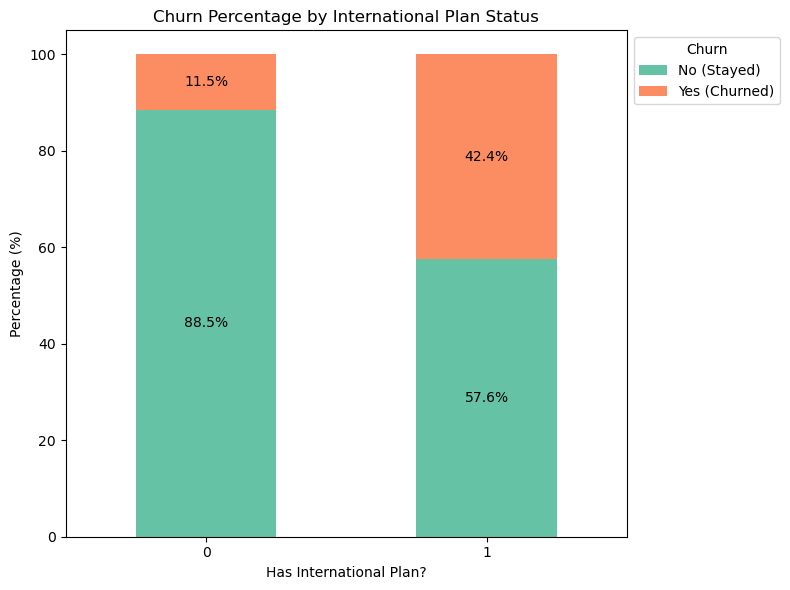

In [7]:
# Calculate the percentages
# pd.crosstab with normalize='index' converts the counts into row proportions
crosstab_percent = pd.crosstab(df['international plan'], df['churn'], normalize='index') * 100

# Create a 100% stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
crosstab_percent.plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], ax=ax)

# Add formatting and labels
plt.title('Churn Percentage by International Plan Status')
plt.xlabel('Has International Plan?')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'], loc='upper left', bbox_to_anchor=(1, 1))

# Add the text numbers inside the bars for extra clarity
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x+width/2, 
                y+height/2, 
                '{:.1f}%'.format(height), 
                horizontalalignment='center', 
                verticalalignment='center')

# Show the plot
plt.tight_layout()
plt.show()

88% of those without international plans stayed while only 57% of those with international plans stayed. Translating this to probabilities, there is a ~89% chance a customer without an international plan stays, while those without have a ~58% chance according to the data we have.

I will visualize the voice mail plan as well:

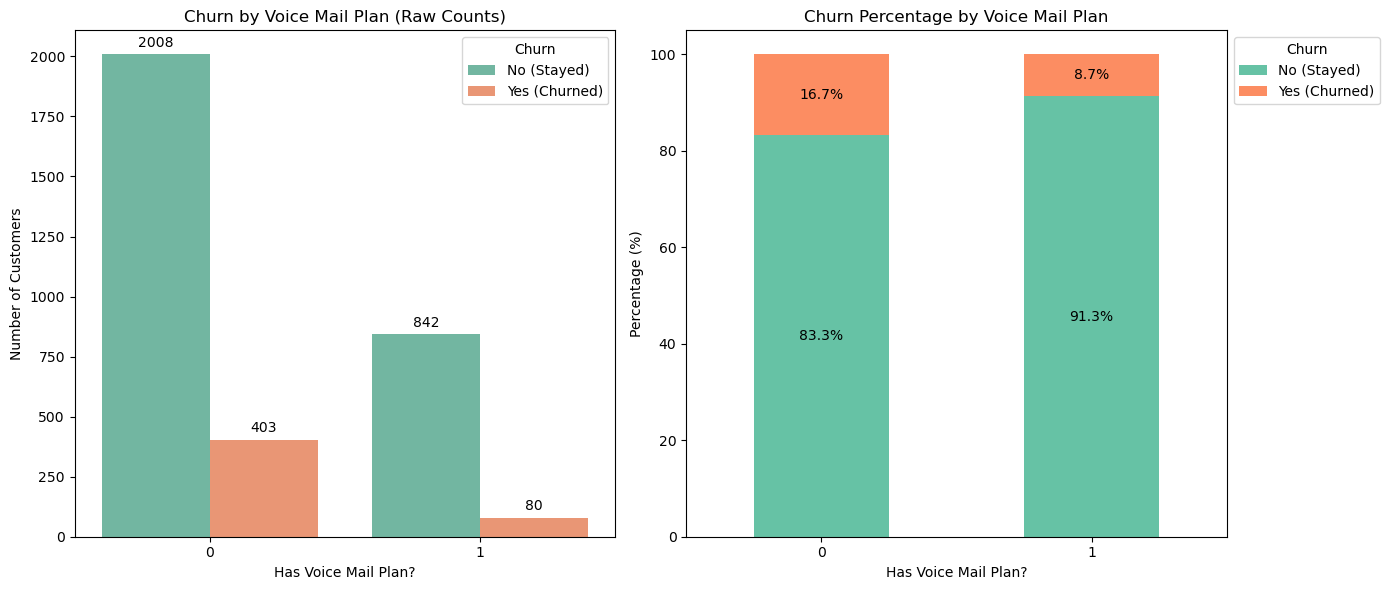

In [8]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# Subplot 1: Raw Counts (Left Side)
# ==========================================
sns.countplot(data=df, x='voice mail plan', hue='churn', palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Voice Mail Plan (Raw Counts)')
axes[0].set_xlabel('Has Voice Mail Plan?')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'])

# Add text labels on top of the bars for exact counts
for p in axes[0].patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        axes[0].text(p.get_x() + p.get_width()/2., height + 20, 
                     f'{int(height)}', ha='center', va='bottom')

# ==========================================
# Subplot 2: Percentages (Right Side)
# ==========================================
# Calculate percentages across rows
crosstab_percent = pd.crosstab(df['voice mail plan'], df['churn'], normalize='index') * 100

# Plot 100% stacked bar chart
crosstab_percent.plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], ax=axes[1])
axes[1].set_title('Churn Percentage by Voice Mail Plan')
axes[1].set_xlabel('Has Voice Mail Plan?')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'], loc='upper left', bbox_to_anchor=(1, 1))

# Add text labels inside the bars for percentages
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        axes[1].text(x + width/2, y + height/2, 
                     f'{height:.1f}%', ha='center', va='center')

# Clean up the layout and display
plt.tight_layout()
plt.show()

A customer with a voice mail plan is less likely to churn compared to one without.

Another important thing to consider is whether or not there is class imbalance in the dataset. I will examine this:

In [9]:
df['churn'].value_counts(), df['churn'].value_counts(normalize=True)

(churn
 0    2850
 1     483
 Name: count, dtype: int64,
 churn
 0    0.855086
 1    0.144914
 Name: proportion, dtype: float64)

85% of the customers in the dataset did not churn (0). Thus, if we had a model that was just predicting zeroes, we would expect it to get a high accuracy score of 85%. The dataset has class imbalance. I will need to address this if I want to create a good model.

## MODEL CREATION

I will create a Logistic Regression model and a Decision Tree and compare the two to see which is a better classifier

### a) Logisitic Regression

I will start by creating a vanilla logistic regression model with default hyperparameters and see how it performs

### Pre-Processing

In [10]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,371-7191,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,358-1921,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,375-9999,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,330-6626,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


I will start by dropping the `phone number` column as it is of no use in prediction. I will then one hot encode the categorical columns, `state` and `area code`. I will also scale the data set using MinMax Scaler as logisitic regression uses l2 regularization by default which requires the data be scaled.

In [11]:
# Drop phone number column
df_temp = df.drop('phone number', axis=1)

# Do train-test split before OHE to avoid data leakage
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Define target and features
y = df_temp['churn']
X = df_temp.drop('churn', axis=1)

# Use a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026, test_size=0.3)

# One hot encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
X_train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train[['state', 'area code']]),
    index = X_train.index,
    columns = ohe.get_feature_names_out()
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[['state', 'area code']]),
    index = X_test.index,
    columns = ohe.get_feature_names_out()
)
X_train_full = pd.concat(
    [X_train_ohe, X_train.drop(['state', 'area code'], axis=1)],
    axis=1
)
X_test_full = pd.concat(
    [X_test_ohe, X_test.drop(['state', 'area code'], axis=1)],
    axis=1
)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)
X_train_preprocessed = pd.DataFrame(
    X_train_scaled,
    index=X_train_full.index,
    columns=X_train_full.columns
)
X_test_preprocessed = pd.DataFrame(
    X_test_scaled,
    index=X_test_full.index,
    columns=X_test_full.columns
)

# View transformed data
X_train_preprocessed.head(), X_test_preprocessed.head()

(      state_AL  state_AR  ...  total intl charge  customer service calls
 286        0.0       0.0  ...           0.466667                   0.250
 3202       0.0       0.0  ...           0.364706                   0.375
 2626       0.0       0.0  ...           0.666667                   0.250
 729        0.0       0.0  ...           0.709804                   0.000
 88         0.0       0.0  ...           0.576471                   0.250
 
 [5 rows x 69 columns],
       state_AL  state_AR  ...  total intl charge  customer service calls
 994        0.0       0.0  ...           0.550980                   0.375
 2288       0.0       0.0  ...           0.466667                   0.000
 3060       0.0       0.0  ...           0.445098                   0.375
 1463       0.0       0.0  ...           0.401961                   0.125
 1532       0.0       0.0  ...           0.609804                   0.000
 
 [5 rows x 69 columns])

Our training and testing data has now been scaled and one-hot encoded.

### Vanilla Model

In [12]:
from sklearn.linear_model import LogisticRegression

# Use a model with default attributes i.e
# solver='lbfgs' and penalty='l2'
# Use a random state for reproducibility
vanilla_model = LogisticRegression(random_state=2026)

vanilla_model.fit(X_train_preprocessed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Evaluation

I will use the most intuitive metric first: **accuracy**

In [13]:
y_test_preds = vanilla_model.predict(X_test_preprocessed)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_test_preds)

0.855

Remember that our model that simply guessed zeroes had an accuracy around this. Therefore this vanilla model is not any better than a model that simply guesses zeroes. I will also view it's recall, precision and f1 score:

In [14]:
from sklearn.metrics import recall_score, precision_score, f1_score

print(f"Recall: {recall_score(y_test, y_test_preds)}\nPrecision: {precision_score(y_test, y_test_preds)}\nF1 Score: {f1_score(y_test, y_test_preds)}")

Recall: 0.225
Precision: 0.631578947368421
F1 Score: 0.3317972350230415


The model has terrible recall (0.225). This means that out of the people who churned our model is predict only 22.5% of them. 

> **NB**: The main purpose of our model is to predict whether or not a customer will leave the company (a 1). Therefore any model we create must have a decent recall. This model having a very low recall is a major downside.

Our f1 score is also bad. This shows that our vanilla mode is an overall bad predictor, which is to be expected as we have done no hyperparameter tuning and pruning. We need to address the class imbalance if we are to create a better model. I will do this in two ways: **using class weights** and **oversampling (SMOTE)**

### Using class weights

I will create models with various class weights and plot their accuracy scores.

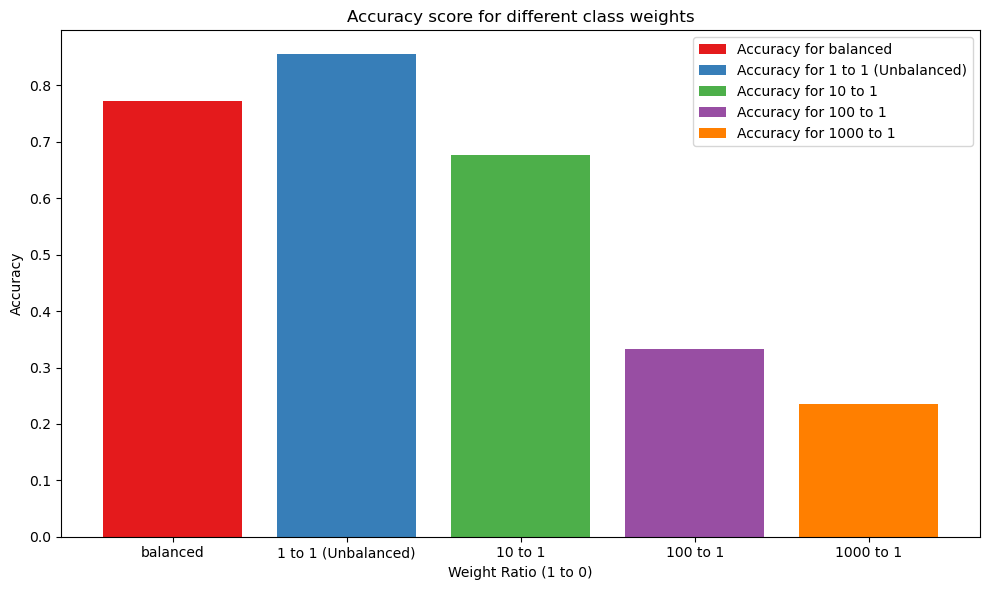

In [ ]:
class_weights = ['balanced', {0: 1, 1: 1}, {0: 1, 1: 10}, {0: 1, 1: 100}, {0: 1, 1: 1000}]
names = ['balanced', '1 to 1 (Unbalanced)', '10 to 1', '100 to 1', '1000 to 1']
colors = sns.color_palette('Set1', n_colors=len(class_weights))
plt.figure(figsize=(10, 6))

for n, cw in enumerate(class_weights):
    # Create logreg model that uses class_weight and fit it
    logreg = LogisticRegression(class_weight=cw, random_state=2026)
    logreg.fit(X_train_preprocessed, y_train)

    # Make predictions
    y_test_preds = logreg.predict(X_test_preprocessed)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_test_preds)

    # Plot
    plt.bar(
        names[n], 
        accuracy, 
        color=colors[n], 
        label=f"Accuracy for model {names[n]}"
    )

# Formatting
plt.title("Accuracy score for different class weights")
plt.xlabel("Weight Ratio (1 to 0)")
plt.ylabel("Accuracy")
plt.legend(loc='best')

# Display
plt.tight_layout()
plt.show()

The more we penalize the model for getting 1 wrong (by increasing the class 1 weight), the more 1's the model predicts and the less accurate it is on the majority class, 0 leading to a drop in our accuracy.

The True Positive Rate increases, however, as the model learns to predict 1's more accurately. To see this, I will plot the Recall scores using various weights:

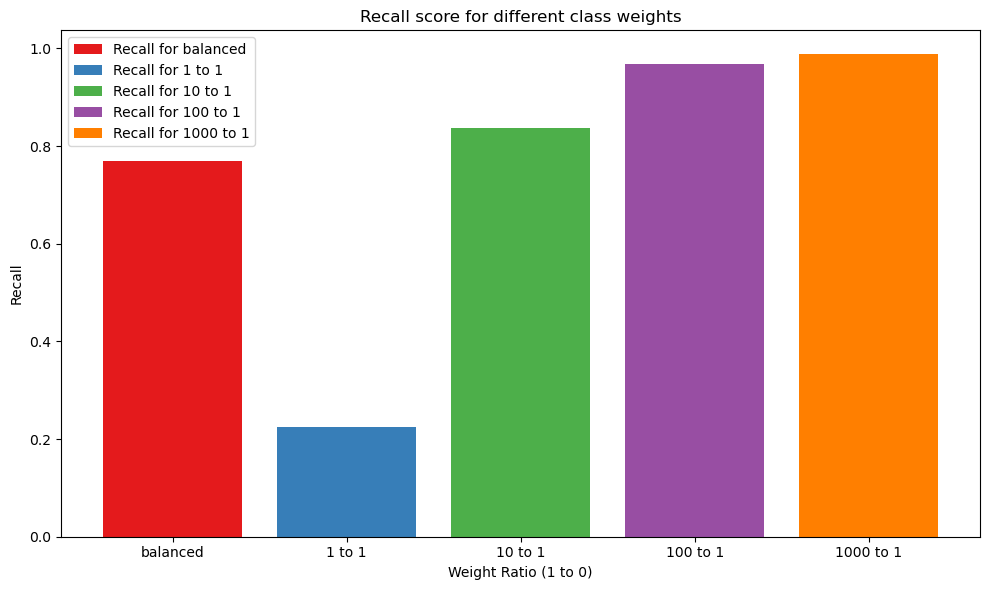

In [ ]:
class_weights = ['balanced', {0: 1, 1: 1}, {0: 1, 1: 10}, {0: 1, 1: 100}, {0: 1, 1: 1000}]
names = ['balanced', '1 to 1 (Unbalanced)', '10 to 1', '100 to 1', '1000 to 1']
colors = sns.color_palette('Set1', n_colors=len(class_weights))
plt.figure(figsize=(10, 6))

for n, cw in enumerate(class_weights):
    # Create logreg model that uses class_weight and fit it
    logreg = LogisticRegression(class_weight=cw, random_state=2026)
    logreg.fit(X_train_preprocessed, y_train)

    # Make predictions
    y_test_preds = logreg.predict(X_test_preprocessed)

    # Calculate recall
    recall = recall_score(y_test, y_test_preds)

    # Plot
    plt.bar(
        names[n], 
        recall, 
        color=colors[n], 
        label=f"Recall for model {names[n]}"
    )

# Formatting
plt.title("Recall score for different class weights")
plt.xlabel("Weight Ratio (1 to 0)")
plt.ylabel("Recall")
plt.legend(loc='best')

# Display
plt.tight_layout()
plt.show()

The recall (True Positive Rate) increases as we increase class 1's weight. The model learns to predict the minority class better and better. This comes at the cost, as we saw earlier, of a reduction in accuracy.

I will plot the ROC (Receiver Operating Charcteristic) curve of the various models to get an all-round score:

AUC for balanced: 0.8219270833333334
AUC for 1 to 1: 0.823125
AUC for 10 to 1: 0.8190922619047619
AUC for 100 to 1: 0.8054092261904763
AUC for 1000 to 1: 0.788608630952381


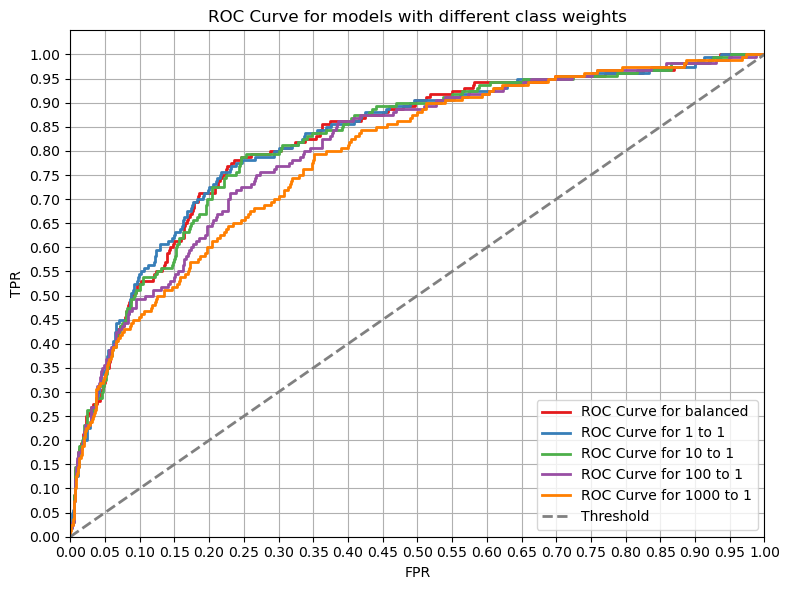

In [ ]:
from sklearn.metrics import roc_curve, auc

class_weights = ['balanced', {0: 1, 1: 1}, {0: 1, 1: 10}, {0: 1, 1: 100}, {0: 1, 1: 1000}]
names = ['balanced', '1 to 1 (Unbalanced)', '10 to 1', '100 to 1', '1000 to 1']
colors = sns.color_palette('Set1', n_colors=len(class_weights))
plt.figure(figsize=(8, 6))

for n, cw in enumerate(class_weights):
    # Create logreg model that uses class_weight and fit it
    logreg = LogisticRegression(class_weight=cw, random_state=2026)
    logreg.fit(X_train_preprocessed, y_train)

    # Get confidence scores
    y_test_scores = logreg.decision_function(X_test_preprocessed)

    # Calculate roc
    fpr, tpr, thresholds = roc_curve(y_test, y_test_scores)
    print(f"AUC for {names[n]}: {auc(fpr, tpr)}")

    # Plot
    plt.plot(
        fpr, 
        tpr, 
        color=colors[n],
        lw=2, 
        label=f"ROC Curve for model {names[n]}"
    )

# Add reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', lw=2, label='Threshold')

# Formatting
plt.grid(True)
plt.xticks([i/20 for i in range(21)])
plt.yticks([i/20 for i in range(21)])
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve for models with different class weights")
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc='best')


# Display
plt.tight_layout()
plt.show()

Here we can see the AUC score **decreases** as the minority class (1) weight increases. This is because of the drop in accuracy we saw earlier.

At this point, I can conclude that the best weighted model is the **balanced** model. It combines a decent accuracy with a decent AUC and, **mainly**, a decent recall score.

> **NB**: The main purpose of our model is to predict whether or not a customer will leave the company (a 1). Therefore any model we create must have a decent recall.

I will record this:

In [22]:
best_weighted_model = LogisticRegression(random_state=2026, class_weight='balanced')
best_weighted_model.fit(X_train_preprocessed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### Using SMOTE

In this section I will SMOTE to oversample the minority class and train a model on the oversampled dataset.

In [ ]:
from imblearn.over_sampling import SMOTE

# Create a SMOTE() object with default sampling strategy
smote_obj = SMOTE()

X_train_smote, y_train_smote = smote_obj.fit_resample(X_train_preprocessed, y_train)

# View the counts. They should be equal now
y_train_smote.value_counts()

churn
0    2010
1    2010
Name: count, dtype: int64

I will now train a logistic regression model using this oversampled data:

In [26]:
oversampled_log_reg = LogisticRegression(random_state=2026)

oversampled_log_reg.fit(X_train_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",2026
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

I will now evaluate the model:

In [30]:
weighted_y_test_pred = best_weighted_model.predict(X_test_preprocessed)
oversampled_y_test_pred = oversampled_log_reg.predict(X_test_preprocessed)

print(
    "Balanced Model:\n" 
    f"   Accuracy: {accuracy_score(y_test, weighted_y_test_pred)}\n" \
    f"   Precision: {precision_score(y_test, weighted_y_test_pred)}\n" \
    f"   Recall: {recall_score(y_test, weighted_y_test_pred)}\n" \
    f"   F1 score: {f1_score(y_test, weighted_y_test_pred)}\n" \
    "Oversampled Model:\n" \
    f"   Accuracy: {accuracy_score(y_test, oversampled_y_test_pred)}\n" \
    f"   Precision: {precision_score(y_test, oversampled_y_test_pred)}\n" \
    f"   Recall: {recall_score(y_test, oversampled_y_test_pred)}\n" \
    f"   F1 score: {f1_score(y_test, oversampled_y_test_pred)}\n"
)

Balanced Model:
   Accuracy: 0.773
   Precision: 0.3929712460063898
   Recall: 0.76875
   F1 score: 0.5200845665961945
Oversampled Model:
   Accuracy: 0.763
   Precision: 0.37540453074433655
   Recall: 0.725
   F1 score: 0.4946695095948827



Visualizing:

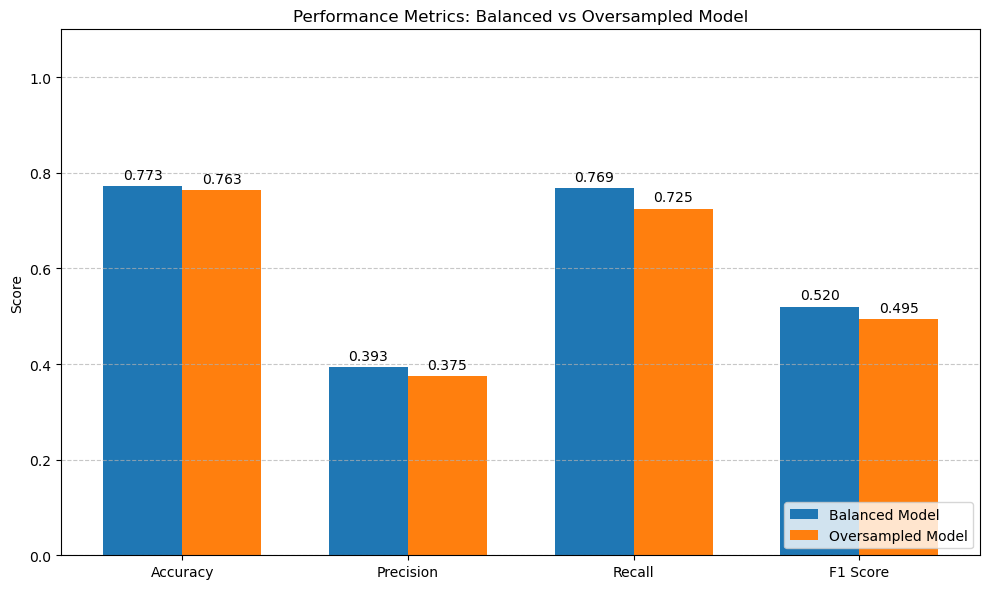

In [31]:
import numpy as np


# 1. Calculate the metrics for both models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Calculate scores for the Balanced Model
balanced_scores = [
    accuracy_score(y_test, weighted_y_test_pred),
    precision_score(y_test, weighted_y_test_pred),
    recall_score(y_test, weighted_y_test_pred),
    f1_score(y_test, weighted_y_test_pred)
]

# Calculate scores for the Oversampled Model
oversampled_scores = [
    accuracy_score(y_test, oversampled_y_test_pred),
    precision_score(y_test, oversampled_y_test_pred),
    recall_score(y_test, oversampled_y_test_pred),
    f1_score(y_test, oversampled_y_test_pred)
]

# 2. Package the data into a dictionary for easy looping
data = {
    'Balanced Model': balanced_scores,
    'Oversampled Model': oversampled_scores
}

# 3. Set up the figure and bar positions
x = np.arange(len(metrics))  # The label locations: [0, 1, 2, 3]
width = 0.35                 # The width of the bars
multiplier = 0               # Counter for our offset

fig, ax = plt.subplots(figsize=(10, 6))

# 4. Loop through the data to plot the grouped bars
for model_name, scores in data.items():
    offset = width * multiplier
    
    # Plot the bars for this specific model
    rects = ax.bar(x + offset, scores, width, label=model_name)
    
    # Add text labels on top of the bars (formatted to 3 decimal places)
    ax.bar_label(rects, fmt='%.3f', padding=3)
    
    multiplier += 1

# 5. Add formatting, titles, and labels
ax.set_ylabel('Score')
ax.set_title('Performance Metrics: Balanced vs Oversampled Model')
# Center the x-tick labels between the two bars
ax.set_xticks(x + width / 2, metrics)
ax.set_ylim([0, 1.1]) # Give some extra room at the top for the labels
ax.legend(loc='lower right') # Move legend out of the way of the bars

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The two models have almost similar metrics but the balanced model is better in every metric. It is the one I shall use as the best logistic regression model.

### b) Decision Tree

